In [10]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime, timedelta
import seaborn as sns
import shapely
import plotting

In [11]:
gdf_track_info = gpd.read_parquet("../data/cleaned/track_info.parquet")
gdf_track_info.sample(5)

,track_file,track_file_datetime,track_file_date,day_of_week,start_datetime,end_datetime,num_pauses,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m),year,season,region,start_point,end_point,track_line
523,/Users/ryansponzilli/Developer/Python Projects...,2021-10-02 07:25:00-05:00,2021-10-02,Saturday,2021-10-02 12:18:57+00:00,2021-10-02 12:25:24+00:00,2,0 days 00:06:30,0 days 00:06:25,0.763138,8.419531,6.345169,-5.697083,Junior,XC Season,School/Fox Chase,POINT (-88.27994 41.92879),POINT (-88.27963 41.9282),"MULTILINESTRING ((-88.27994 41.92879, -88.2799..."
655,/Users/ryansponzilli/Developer/Python Projects...,2022-10-01 08:28:00-05:00,2022-10-01,Saturday,2022-10-01 13:18:10+00:00,2022-10-01 15:50:32+00:00,4,0 days 00:20:56,0 days 00:20:40,2.374189,8.504215,47.995715,-46.943518,Senior,XC Season,LeRoy/Great West,POINT (-88.35012 41.92484),POINT (-88.34931 41.92738),"MULTILINESTRING ((-88.35012 41.92484, -88.3501..."
307,/Users/ryansponzilli/Developer/Python Projects...,2021-01-09 11:10:00-06:00,2021-01-09,Saturday,2021-01-09 16:15:48+00:00,2021-01-09 17:10:05+00:00,2,0 days 00:50:02,0 days 00:49:56,5.871518,8.437562,57.141936,-74.514998,Sophomore,Winter Training,Potwat/Bethlehem,POINT (-88.31216 41.92023),POINT (-88.31568 41.92016),"MULTILINESTRING ((-88.31216 41.92023, -88.3121..."
293,/Users/ryansponzilli/Developer/Python Projects...,2020-12-19 11:21:00-06:00,2020-12-19,Saturday,2020-12-19 16:13:01+00:00,2020-12-19 17:21:28+00:00,20,0 days 01:01:28,0 days 00:49:40,6.016891,7.998866,70.849409,-69.751890,Sophomore,Winter Training,School/Fox Chase,POINT (-88.29129 41.92943),POINT (-88.2912 41.92964),"MULTILINESTRING ((-88.29129 41.92943, -88.2913..."
202,/Users/ryansponzilli/Developer/Python Projects...,2020-07-27 07:41:00-05:00,2020-07-27,Monday,2020-07-27 12:09:26+00:00,2020-07-27 12:41:08+00:00,1,0 days 00:31:42,0 days 00:29:51,3.507075,8.448552,50.150377,-49.253023,Sophomore,Summer Training,Home,POINT (-88.28581 41.90488),POINT (-88.28719 41.90454),"MULTILINESTRING ((-88.28581 41.90488, -88.2858..."


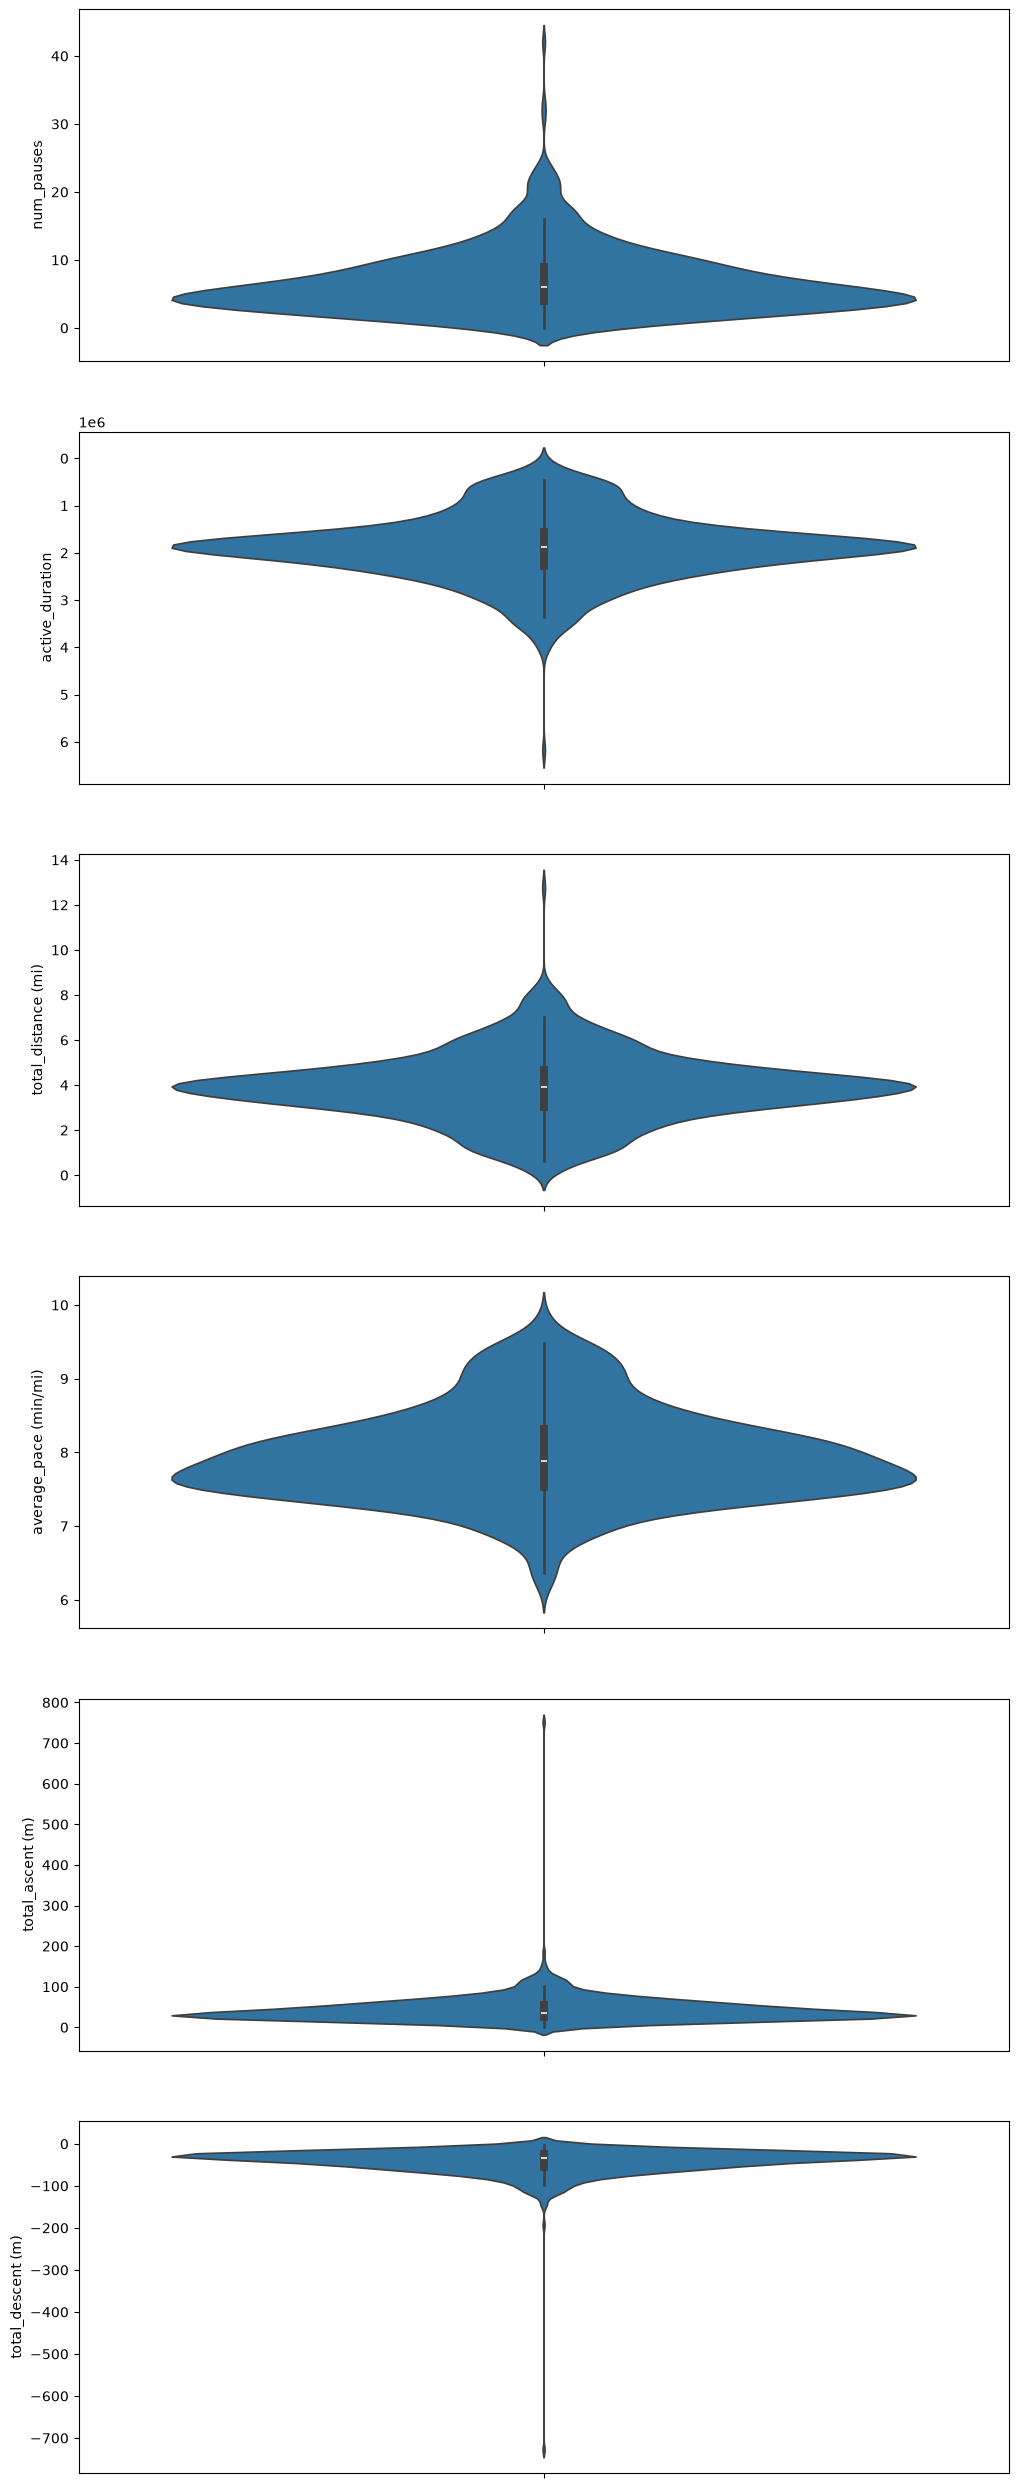

In [12]:
fig, ax = plt.subplots(6, 1, figsize=(12, 32))
for i, col in enumerate(["num_pauses", "active_duration", "total_distance (mi)", "average_pace (min/mi)", "total_ascent (m)", "total_descent (m)"]):
    sns.violinplot(gdf_track_info[col], ax=ax[i])

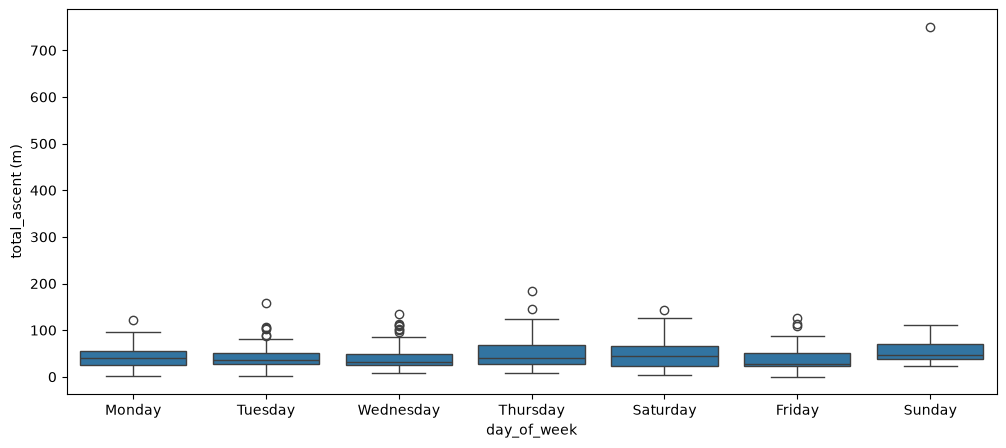

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(x=gdf_track_info['day_of_week'], y=gdf_track_info['total_ascent (m)'])
plt.show()

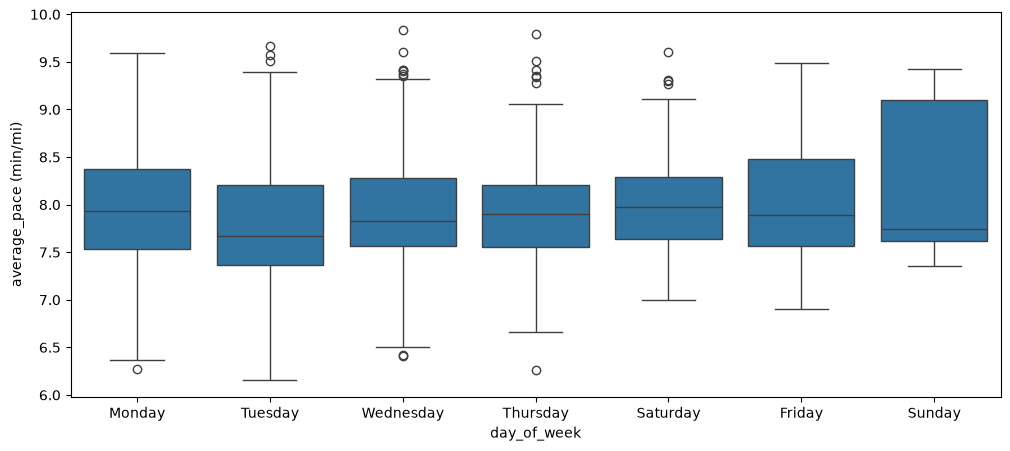

In [14]:
plt.figure(figsize=(12,5))
sns.boxplot(x=gdf_track_info['day_of_week'], y=gdf_track_info['average_pace (min/mi)'])
plt.show()

Text(0.5, 1.0, 'Pace Evolution')

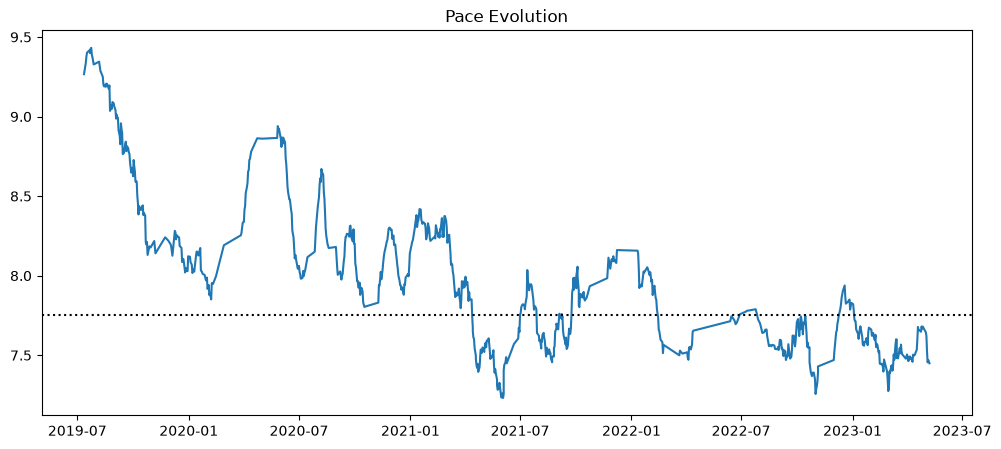

In [15]:
plt.figure(figsize=(12,5))
temp = gdf_track_info.loc[~gdf_track_info['average_pace (min/mi)'].isna()]
plt.plot(temp['track_file_date'], temp['average_pace (min/mi)'].rolling(14).mean())
plt.axhline(7.75, ls='dotted', color='k')
plt.title("Pace Evolution")

/var/folders/41/_gkgvhb94wd4156zplzr4cg00000gn/T/ipykernel_19970/4267235779.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(week=lambda df: df['track_file_datetime'].dt.to_period('W').dt.start_time)


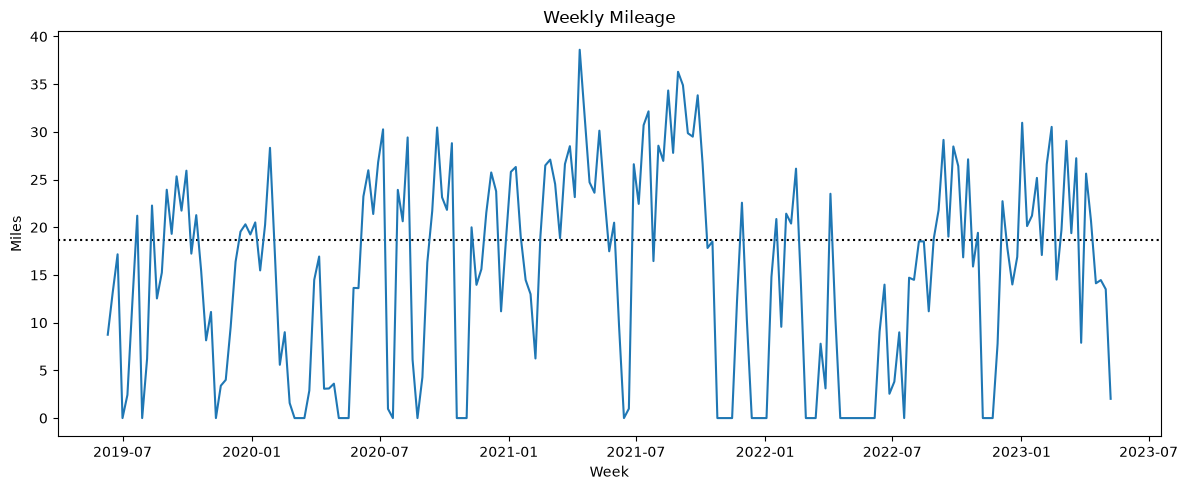

In [16]:
plt.figure(figsize=(12, 5))

weekly = (
    gdf_track_info
    .assign(week=lambda df: df['track_file_datetime'].dt.to_period('W').dt.start_time)
    .groupby('week')['total_distance (mi)']
    .sum()
)

plt.axhline(weekly.mean(), ls='dotted', color='k')

weekly = (
    weekly
    .asfreq('W-MON', fill_value=0)
)

plt.plot(weekly.index, weekly.values)
plt.xlabel("Week")
plt.ylabel("Miles")
plt.title("Weekly Mileage")
plt.tight_layout()


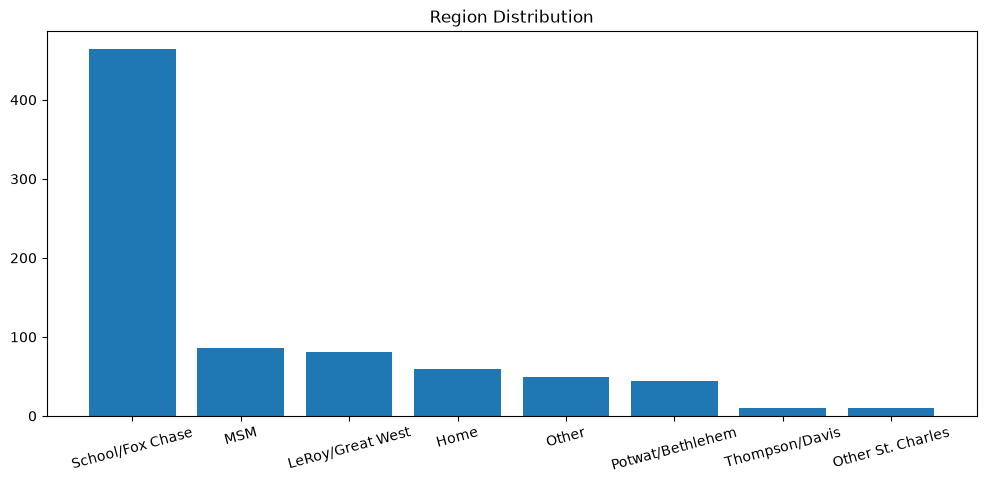

In [17]:
plt.figure(figsize=(12, 5))
plt.bar(gdf_track_info['region'].value_counts().index, gdf_track_info['region'].value_counts().values)
plt.xticks(rotation=15)
plt.title("Region Distribution")
plt.show()

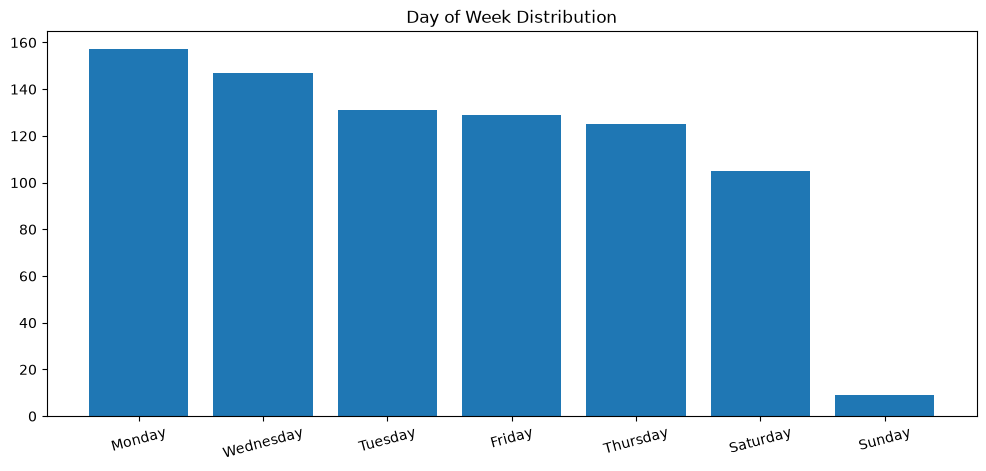

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(gdf_track_info['day_of_week'].value_counts().index, gdf_track_info['day_of_week'].value_counts().values)
plt.xticks(rotation=15)
plt.title("Day of Week Distribution")
plt.show()